# **Simulación Cuántica de modelos físicos mediante descomposición de Trotter en Pennylane**

### Ana Maria Arcila Ortiz, Melissa Estrada Murillo
##### Instituto de Física, Universidad de Antioquia, Colombia
##### Introducción a la computacion Cuantica, Profesor Sebastian Duque Mesa, 2025-1

## 1. Introducción

Una de las aplicaciones más relevantes de los computadores, ya sean clásicos o cuánticos, es la simulación de sistemas físicos. Estas simulaciones se centran principalmente en estudiar la dinámica del sistema, es decir, saber cómo evolucionará el sistema después de un cierto tiempo, dado el estado inicial del sistema y las reglas de la dinámica que por lo general se describen mediante ecuaciones diferenciales.

La simulación de sistemas cuánticos es, en principio, posible mediante computadoras clásicas. Sin embargo, esta tarea resulta cada vez más compleja, ya que el tiempo de cálculo requerido crece de manera exponencial con el tamaño del sistema. Por ejemplo, para simular un sistema de con $n$ qubits es necesario resolver aproximadamente $2^n$ ecuaciones diferenciales [1]. Por lo tanto, existen sistemas cuánticos cuya simulación clásica resulta intratable. Una alternativa natural para superar esta limitación es utilizar dispositivos que obedezcan las mismas leyes que los sistemas a simular: los computadores cuánticos. Estos permiten representar y manipular estados cuánticos de forma directa, reduciendo drásticamente el coste de simulación para un amplio rango de Hamiltonianos de interés físico. En particular, modelos como el de Ising de campo transversal, el tight-binding o el modelo de Hubbard, que son de gran relevancia en magnetismo, transporte electrónico y física de materiales, los cuales pueden implementarse eficientemente en un computador cuántico.

En este contexto, el presente trabajo se enfoca en el diseño y ejecución de simulaciones cuánticas del modelo de Ising de campo transversal y del modelo tight-binding, empleando la plataforma PennyLane y basándose en la descomposición de Trotter para aproximar la evolución temporal gobernada por sus respectivos Hamiltonianos.

## 2. Marco teorico

### Simulación cuántica
La evolución temporal de un sistema cuántico está descrita por la ecuación de Schrödinger dependiente del tiempo:

\begin{equation}
i\frac{\partial}{\partial t} |\psi(t)\rangle = H |\psi(t)\rangle,
\end{equation}

cuya solución para un $H$ independiente del tiempo es:

\begin{equation}
|\psi(t)\rangle = e^{-iHt} |\psi(0)\rangle,
\end{equation}

Donde $e^{-iHt}$ es el operador de evolución temporal. Este operador encapsula la dinámica del sistema cuántico a lo largo del tiempo y constituye el foco central de las simulaciones cuánticas.

En sistemas físicos reales, el Hamiltoniano $H$ suele ser una suma de términos que representan interacciones locales:

\begin{equation}
H = \sum_{k=1}^L H_k,
\end{equation}

donde cada $H_k $ actúa sobre un número reducido de partículas o grados de libertad. En consecuencia, aunque $e^{-iHt}$ resulta difícil de computar, $e^{-iH_kt}$ actúa sobre un subsistema mucho más pequeño y, por tanto, es más sencillo de aproximar mediante circuitos cuánticos.  Sin embargo, dado que en general $[H_j,H_k]\neq 0$, no es posible factorizar la evolución total como $e^{-iHt}\neq\prod_k e^{-iH_kt}$. En cambio, si es posible usando la fórmula de Trotter.

#### Descomposición de Trotter
Sean $A$ y $B$ operadores hermiticos. La fórmula de Trotter establece que, para cualquier $t$ real, se cumple:

\begin{equation}
e^{-i(A+B)t} = \lim_{n\to\infty} \left( e^{-iA t/n} e^{-iB t/n} \right)^n,
\end{equation}

En la práctica, se utiliza un número finito de pasos $n$, obteniéndose la descomposición de Trotter, que introduce un error controlado.

En su forma de primer orden:

\begin{equation}
e^{-i(A+B)t} = (e^{-iAt/n} e^{-iBt/n})^n+ \mathcal{O}\left(\frac{1}{n}\right),
\end{equation}

o en forma simétrica de segundo orden:

\begin{equation}
e^{-i(A+B)t} = (e^{-iAt/{2n}} e^{-iBt/n} e^{-iAt/{2n}})^n + \mathcal{O}\left(\frac{1}{n^2}\right)
\end{equation}

Realizando modificaciones en la descomposición de Trotter se pueden obtener aproximaciones de orden superior para realizar simulaciones cuánticas [1].

Esta técnica permite implementar la evolución temporal como una secuencia de operadores unitarios más simples, cada uno de los cuales puede realizarse mediante un circuito cuántico eficiente.

Por ejemplo, consideremos el siguiente hamiltoniano:

\begin{equation}
H=H_1+H_2+\cdots +H_L
\end{equation}

La descomposicion de Trotter se escribe como:

\begin{align}
U(t)=e^{-iHt}=e^{-i(H_1+...+H_L)t}=(U_1(t/n)U_2(t/n)\cdots U_L(t/n))^n+\mathcal{O}(t^2/n)
\end{align}

donde $U_k(t)=e^{-iH_kt}$ y $n$ es el número de pasos de Trotter. Aumentar $n$ mejora la precisión de la aproximación. Lo anterior, en forma de circuito, se observa en la siguiente imagen:

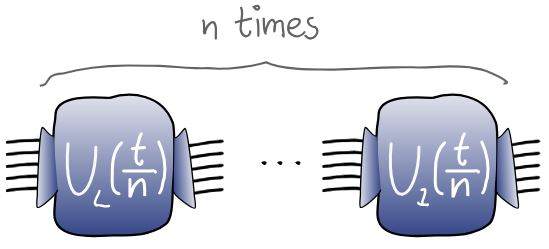

## 3. Código, resultados y analisis

In [ ]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.8/930.8 kB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 73.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 99.6 MB/s eta 0:00:00


In [ ]:
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

### 3.1 Modelo de Ising con campo magnetico transversal

El modelo de Ising es un sistema ampliamente utilizado en física estadística y mecánica cuántica para describir interacciones de espines vecinos dispuestos en una red. Cada sitio de la red está asociado a una variable discreta $\sigma_k ∈\{−1,+1\}$, que representa el estado de espín de la partícula en dicha posición. Donde la configuración completa del sistema se describe mediante el conjunto $\sigma=\{\sigma_k\}$.

Una extensión relevante es el **modelo de Ising con campo magnético transversal**, en el que además de la interacción tipo Ising entre espines adyacentes, se introduce un campo magnético uniforme aplicado a lo largo del eje $x$. El hamiltoniano que describe el sistema es:
\begin{equation}
H= J\sum_{i=1}^{n} Z_i Z_{i+1} + h \sum_{i=1}^{n} X_i,
\end{equation}
donde $J$ es la constante de acoplamiento, es decir, la fuerza de interacción de los espines, $n$ es el numero de particulas con espin (qubits), $Z_i$ es la componente $z$ del espin de la particula $i$-esima, $h$ la intensidad del campo magnetico transversal y $X_i$ es el operador de pauli que representa la magnetización de la particula $i$-esima en la direccion $x$. Por lo tanto, El primer término describe la interacción entre espines vecinos en la dirección $z$, mientras que el segundo representa la acción del campo en la dirección
$x$.

A continuación implementaremos la descomposición de Trotter para $e^{-iHt}$ con el fin de estudiar como evoluciona la magnetización total del sistema con el tiempo. Para ello debemos entender como implementar las compuertas $e^{-i\delta Z_i Z_{i+1}}$ y $e^{-i\delta hX_i}$:

\begin{align}
  e^{-i\delta Z_i Z_{i+1}}&=\text{CNOT}_{i,i+1}e^{-i\delta Z_{i+1}}\text{CNOT}_{i,i+1}\\
  e^{-i\delta hX_i}&=RX(2h\delta)
\end{align}
donde $RX(\theta)$ es la puerta de rotación alrededor del eje $x$.




In [ ]:
#Parametros
n_qubits= 6    # Consideramos un sistema con 6 particulas (6 quibts = 6 espines)
time=3         # Tiempo total de la simulacion
N=100          # Numero de pasos de la descomposicion de Trotter
delta=time/N   # Paso de tiempo
J=1            # Constante de acomplamiento
h=3            # Campo magnetico transversal

In [ ]:
# Creamos un dispositivo cuantico
dev = qml.device("default.qubit", wires=range(n_qubits))

# Observable de magnetizacion
def magnetizacion_total():
    return sum(qml.PauliZ(wires=i)for i in range(n_qubits))/n_qubits

@qml.qnode(dev)
def circuito_ising_trotter_h(J,h,steps):
    # Estado inicial |000000⟩ (opcional: explícito)
    qml.BasisState(np.array([0]*n_qubits), wires=range(n_qubits))

    for _ in range(steps):
        for i in range(n_qubits):

          #Se puede usar dos implementaciones que son equivalentes
          #Opcion 1: qml.IsingZZ --> equivale a las 3 compuertas CNOT-RZ-CNOT
          #qml.IsingZZ(2*J*delta, wires=[i, (i + 1) % n_qubits]) #Garantizamos condiciones de contorno periodicas

          #Opcion 2: Descomposición CNOT-RZ-CNOT
          qml.CNOT(wires=[i, (i + 1) % n_qubits]) #Garantizamos condiciones de contorno periodicas
          qml.RZ(2*J*delta,wires=(i + 1) % n_qubits) #Garantizamos condiciones de contorno periodicas
          qml.CNOT(wires=[i, (i + 1) % n_qubits]) #Garantizamos condiciones de contorno periodicas

        if h != 0:
            for i in range(n_qubits):
                qml.RX(2*h*delta,wires=i)

    return qml.expval(magnetizacion_total())

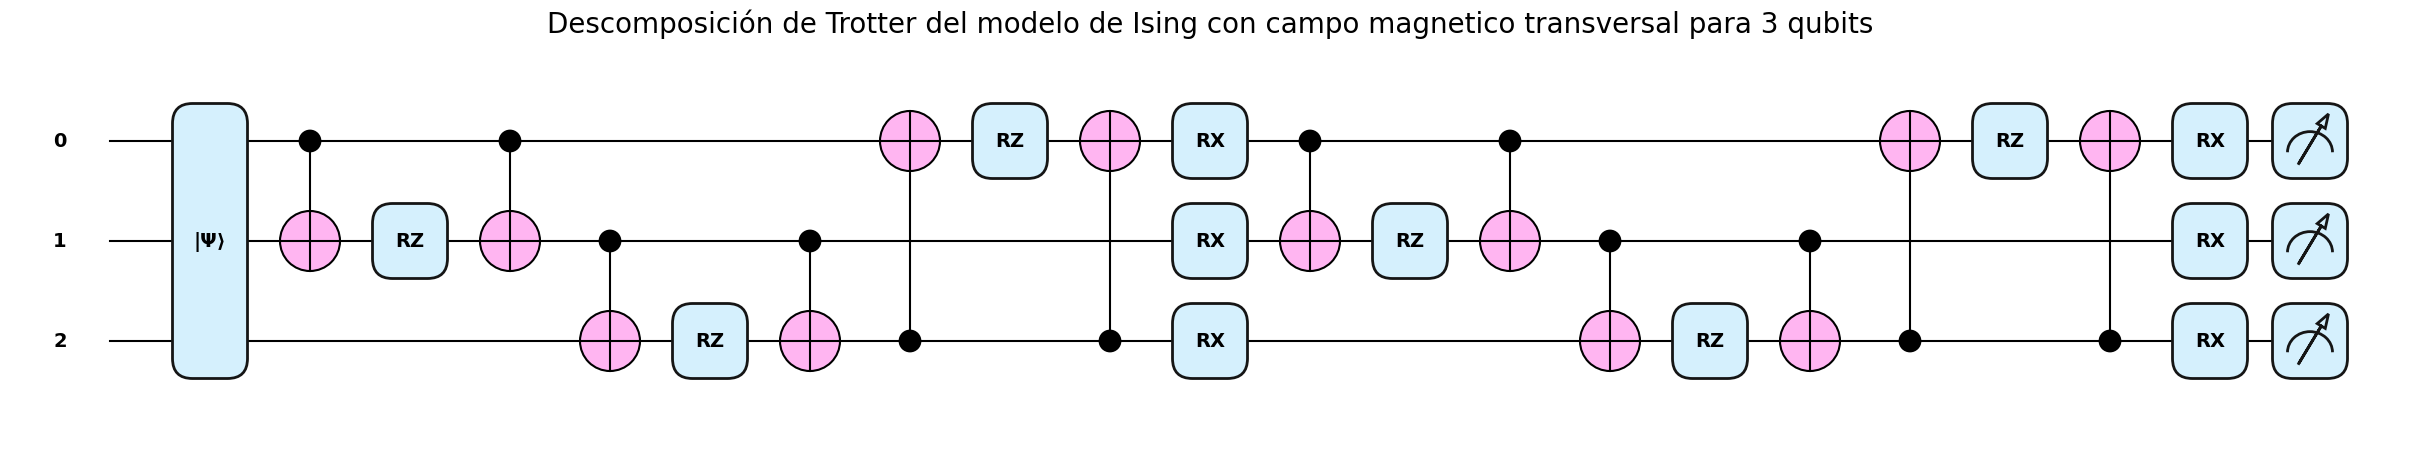

In [ ]:
qml.drawer.use_style("pennylane")
fig, ax = qml.draw_mpl(circuito_ising_trotter_h)(J, h, 2)
plt.title("Descomposición de Trotter del modelo de Ising con campo magnetico transversal para 3 qubits", fontsize=20)
plt.show()

In [ ]:
#Simulacion de la magnetizacion en el tiempo sin campo
x_h=np.linspace(0,0.6,N+1)
y_h_trotter=[circuito_ising_trotter_h(J,0,steps=i) for i in range(N+1)]

In [ ]:
#Simulacion de la magnetizacion en el tiempo en presencia del campo
x_h_campo=np.linspace(0,time,N+1)
y_h_trotter_campo=[circuito_ising_trotter_h(J,h,steps=i) for i in range(N+1)]
y_h_trotter_campo_2=[circuito_ising_trotter_h(J,10,steps=i) for i in range(N+1)]
y_h_trotter_campo_3=[circuito_ising_trotter_h(J,20,steps=i) for i in range(N+1)]

Text(0.5, 1.0, 'Con campo magnetico $h=20$')

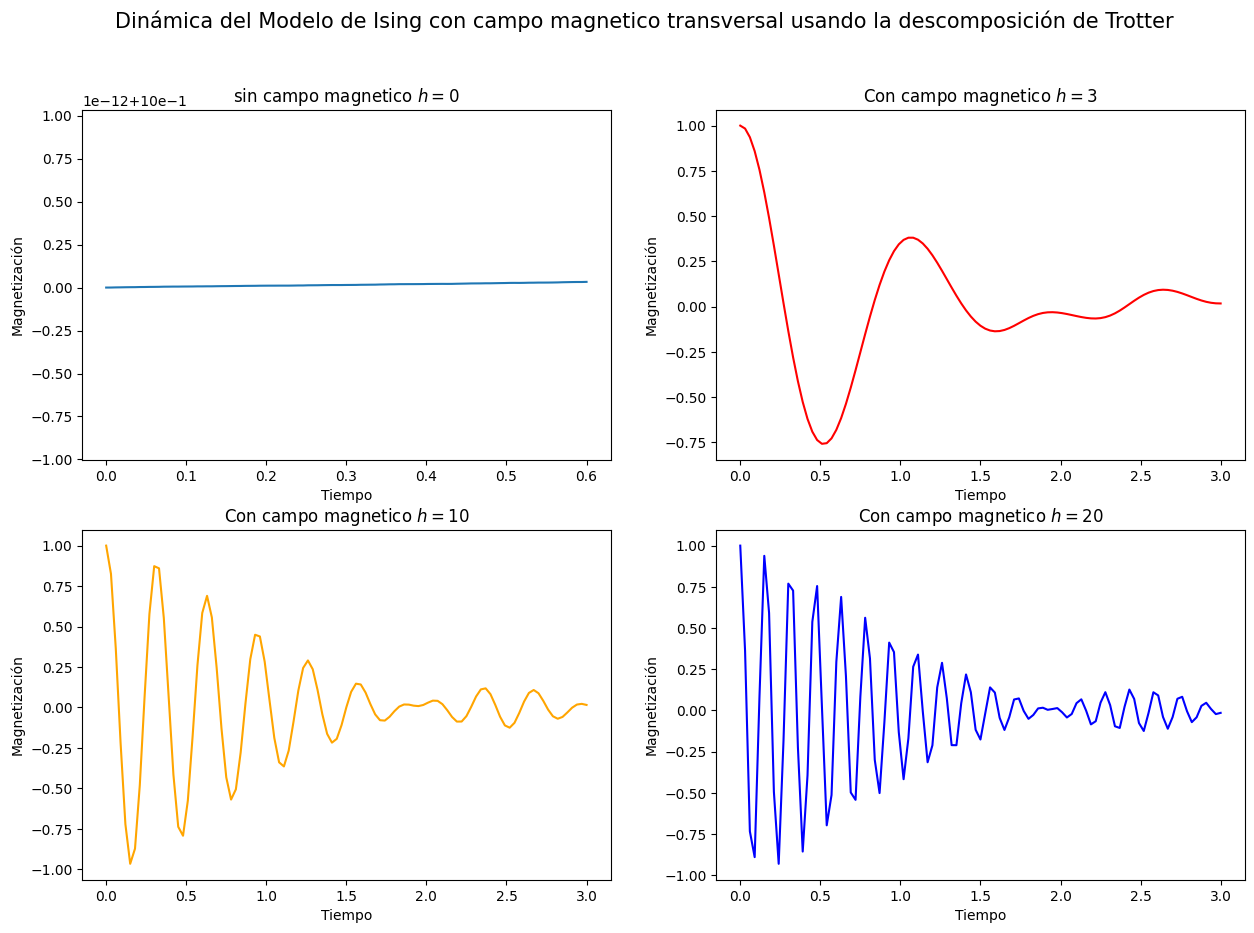

In [ ]:
# Dibujar el gráfico
fig, ax = plt.subplots(2,2,figsize=(15, 10))
fig.suptitle("Dinámica del Modelo de Ising con campo magnetico transversal usando la descomposición de Trotter", fontsize=15)

ax[0,0].plot(x_h, y_h_trotter)
ax[0,0].set_xlabel("Tiempo")
ax[0,0].set_ylabel("Magnetización")
ax[0,0].set_title("sin campo magnetico $h=0$")

ax[0,1].plot(x_h_campo, y_h_trotter_campo, color="red")
ax[0,1].set_xlabel("Tiempo")
ax[0,1].set_ylabel("Magnetización")
ax[0,1].set_title("Con campo magnetico $h=3$")

ax[1,0].plot(x_h_campo, y_h_trotter_campo_2, color="orange")
ax[1,0].set_xlabel("Tiempo")
ax[1,0].set_ylabel("Magnetización")
ax[1,0].set_title("Con campo magnetico $h=10$")

ax[1,1].plot(x_h_campo, y_h_trotter_campo_3, color="blue")
ax[1,1].set_xlabel("Tiempo")
ax[1,1].set_ylabel("Magnetización")
ax[1,1].set_title("Con campo magnetico $h=20$")




En la primera gráfica vemos que para el modelo de ising sin campo magnético transversal $h=0$, la magnetización se mantiene prácticamente constante en el tiempo, esto es consistente con el hecho de que sin campo transversal, el hamiltoniano es puramente de interacción y no hay nada que rote los espines.

En cambio, en la segunda gráfica, donde hay presencia de un campo magnético transversal $h=3$ se observa cómo la magnetización total del sistema varía en el tiempo. Vemos oscilaciones amortiguadas, donde el campo transversal rompe la conservación de la magnetización en $z$, generando transiciones entre estados de espín. Es decir, que el campo magnético transversal hace que los espines que están alineados en la dirección $z$ se desorganizan, lo que resulta en un cambio en la magnetización total. También vemos que la amplitud disminuye con el tiempo y se tiende a estabilizar.

En las siguientes gráficas $h=10$ y $h=20$, se observa que las oscilaciones son mucho más rápidas, aumentan la frecuencia y decae la amplitud mucho más rapido, vemos que el termino en que representa la acción del campo comienza a dominar.

Ahora comparemos el resultado anterior usando directamente una libreria de pennylane que hace las descomposición de Trotter dierctamente llamada qml.ApproxTimeEvolution

In [ ]:
# Circuito de evolución aproximada con ApproxTimeEvolution
@qml.qnode(dev)
def circuito_aprox(t, trotter_steps):  # t es el tiempo total de evolución
    qml.BasisState(np.array([0] * n_qubits), wires=range(n_qubits))

    # Definir el Hamiltoniano
    terms = []
    coeffs = []

    for i in range(n_qubits):
        terms.append(qml.PauliZ(i) @ qml.PauliZ((i + 1) % n_qubits))
        coeffs.append(J)
        terms.append(qml.PauliX(i))
        coeffs.append(h)

    H = qml.Hamiltonian(coeffs, terms)

    # Evolución aproximada por Trotter
    qml.ApproxTimeEvolution(H, t, trotter_steps)

    return qml.expval(magnetizacion_total())


# Simulación en el tiempo
x_vals = np.linspace(0, time, N+1)
y_vals = [circuito_aprox(t=ti, trotter_steps=100) for ti in x_vals]


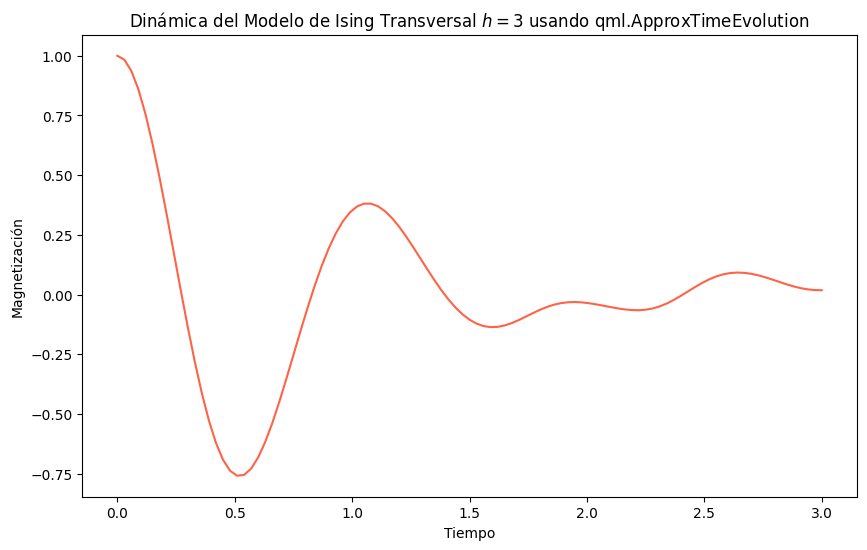

In [ ]:
# Gráfica
plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, color="tomato")
plt.xlabel("Tiempo")
plt.ylabel("Magnetización")
plt.title("Dinámica del Modelo de Ising Transversal $h=3$ usando qml.ApproxTimeEvolution")
plt.show()

Ahora vamos a comparar el resultado obtenido anteriormente con la solución exacta, para observar cual es el error asociado a la descomposición de Trotter

In [ ]:
# Construir Hamiltoniano: H = J Σ Z_i Z_{i+1} + h Σ X_i
H_terms = []
coeffs = []

for i in range(n_qubits):
    # Z_i Z_{i+1}
    H_terms.append(qml.PauliZ(i) @ qml.PauliZ((i + 1) % n_qubits))
    coeffs.append(J)

for i in range(n_qubits):
    # X_i
    H_terms.append(qml.PauliX(i))
    coeffs.append(h)

H = qml.dot(coeffs, H_terms)

In [ ]:
# Obtenemos la matriz completa del Hamiltoniano
H_matrix=qml.matrix(H)

# Diagonalizamos la matriz
eigvals, eigvecs = np.linalg.eigh(H_matrix)

# Operador de evolución exacto
def exact_evolution_operator(time):
    return eigvecs @ np.diag(np.exp(-1j * eigvals * time)) @ eigvecs.conj().T

In [ ]:
# Dispositivo para evolución exacta
dev_exact = qml.device("default.qubit", wires=n_qubits)

# Circuito exacto con evolución usando qml.QubitUnitary
@qml.qnode(dev_exact)
def circuito_exacto_H(time):
    qml.QubitUnitary(exact_evolution_operator(time),wires=range(n_qubits))
    return qml.expval(magnetizacion_total())

In [ ]:
x = np.linspace(0, time, N + 1)
y_exact_H= [circuito_exacto_H(t) for t in x]

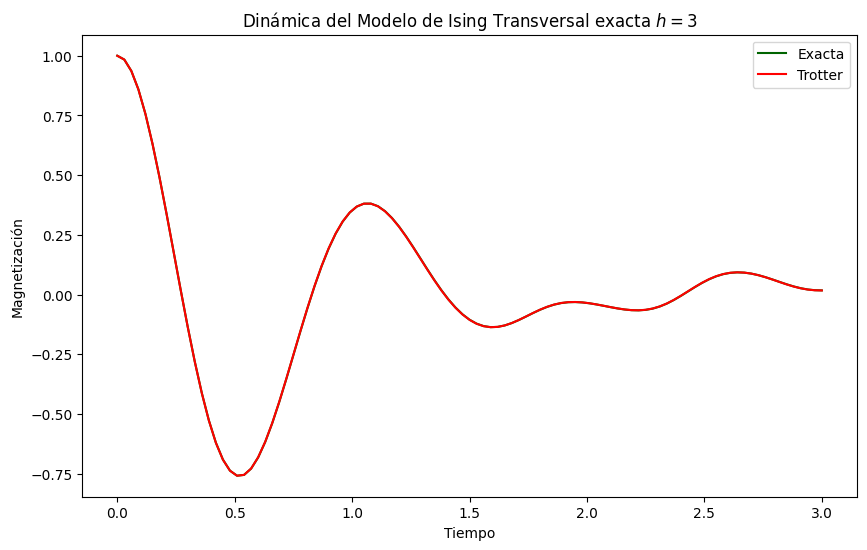

In [ ]:
# Graficar
plt.figure(figsize=(10, 6))
plt.plot(x, y_exact_H, color="darkgreen",label="Exacta")
plt.plot(x_h_campo, y_h_trotter_campo, color="red",label="Trotter")
plt.xlabel("Tiempo")
plt.ylabel("Magnetización")
plt.title("Dinámica del Modelo de Ising Transversal exacta $h=3$")
plt.legend()
plt.show()

En esta grafica la dinamica dada por la solución exacta y la descomposición de Trotter parecen iguales, pero miremos el error.

/tmp/ipython-input-2484886302.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


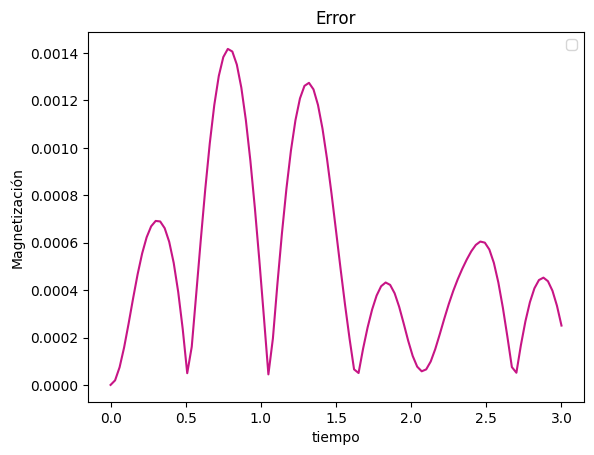

In [ ]:
#Grafica error
plt.xlabel("tiempo")
plt.ylabel("Magnetización")
plt.title("Error")
plt.plot(x, np.abs(np.array(y_h_trotter_campo) - np.array(y_exact_H)), color="mediumvioletred")
plt.legend()
plt.show()

## 3.2 Modelo Tight Binding

También denominado combinación lineal de orbitales atómicos. Es un método computacionalmente veloz de calcular la estructura de bandas y los estados de Bloch de una partícula de cierto material.

Para sistemas de pocas partículas se pueden utilizar otros métodos:

Para $\leq 10$ partículas, se puede utilizar la interacción de configuraciones.

Para cientos o miles de partículas se puede usar DFT.

Para $\geq 10000$ debemos utilizar tight binding.

El modelo de tight binding, si asumimos que no hay defectos e ignoramos los efectos del espín, sigue el Hamiltoniano [4]:

\begin{equation}
H = -\tau \sum_{i=0}^N (c_i^\dagger c_{i+1} + c_{i+1}^\dagger c_i),
\end{equation}

donde

\begin{equation}
c_i^\dagger = Z_0...Z_{i-1}\left(\frac{X_i-iY_i}{2}\right)I_{i+1}...I_N
\end{equation}

\begin{equation}
c_i = Z_0...Z_{i-1}\left(\frac{X_i+iY_i}{2}\right)I_{i+1}...I_N
\end{equation}

y $X_i = \sigma_i^x$, $Y_i = \sigma_i^y$ y $Z_i = \sigma_i^z$ [3]

Por ejemplo, si tenemos una cadena 1D de 5 posiciones, el Hamiltoniano sería:

\begin{equation}
H = -\tau \sum_{i=0}^3 (c_i^\dagger c_{i+1} + c_{i+1}^\dagger c_i),
\end{equation}

Y si tuvieramos un defecto entre las posiciones 2 y 3, sería:

\begin{equation}
H = -\tau \sum_{i=(0, 1, 3)} (c_i^\dagger c_{i+1} + c_{i+1}^\dagger c_i) - \tau_d(c_2^\dagger c_3 + c_3^\dagger c_2),
\end{equation}

donde $\tau$ es la fuerza del salto parametrizada.

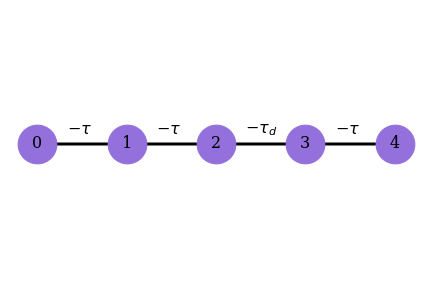

Esto, si aplicamos las definiciones de las $c_i^\dagger$ y $c_i$, nos queda de la forma:

\begin{equation}
H = -\frac{\tau}{2} \sum_{i=(0, 1, 3)} (X_i X_{i+1} + Y_i Y_{i+1}) - \frac{\tau_d}{2}(X_2 X_3 + Y_2 Y_3).
\end{equation}

Y entonces la evolución temporal, sin incluír el defecto es:

\begin{equation}
U(\tau) = \prod_{n=0}^N exp\left[ i\frac{\tau t}{2n}(X_0 X_1 + Y_0 Y_1) \right]^n exp\left[ i\frac{\tau t}{2n}(X_1 X_2 + Y_1 Y_2) \right]^n exp\left[ i\frac{\tau t}{2n}(X_2 X_3 + Y_2 Y_3) \right]^n exp\left[ i\frac{\tau t}{2n}(X_3 X_4 + Y_3 Y_4) \right]^n,
\end{equation}

\begin{equation}
U(\tau, \tau_d) \approx \prod_{n=0}^N exp\left[ i\frac{\tau t}{2n}(X_0 X_1 + Y_0 Y_1) \right]^n exp\left[ i\frac{\tau t}{2n}(X_1 X_2 + Y_1 Y_2) \right]^n exp\left[ i\frac{\tau_d t}{2n}(X_2 X_3 + Y_2 Y_3) \right]^n exp\left[ i\frac{\tau t}{2n}(X_3 X_4 + Y_3 Y_4) \right]^n
\end{equation}

Y las interacciones XX y YY conmutan, por lo que tendríamos la expresión [5]:

\begin{equation}
U(\tau, \tau_d) \approx \prod_{n=0}^N exp\left[ i\frac{\tau t}{2n}(X_0 X_1) \right]^n exp\left[ i\frac{\tau t}{2n}(Y_0 Y_1) \right]^n exp\left[ i\frac{\tau t}{2n}(X_1 X_2) \right]^n exp\left[ i\frac{\tau t}{2n}(Y_1 Y_2) \right]^n exp\left[ i\frac{\tau_d t}{2n}(X_2 X_3) \right]^n exp\left[ i\frac{\tau_d t}{2n}(Y_2 Y_3) \right]^n exp\left[ i\frac{\tau t}{2n}(X_3 X_4) \right]^n exp\left[ i\frac{\tau t}{2n}(Y_3 Y_4) \right]^n.
\end{equation}

In [ ]:
# Definimos las matrices de Pauli
I2 = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)

In [ ]:
def kron_list(mats):
    """Función que define el producto de Kronecker de una lista de matrices."""
    out = mats[0]
    for m in mats[1:]:
        out = qml.math.kron(out, m)
    return out

def pauli_term_on_sites(term_ops, num_sites):
    """Organiza las matrices de Pauli para ser multiplicadas por kron_list
    term_ops: dict {site_index: single_qubit_matrix}
    num_sites: int (tamaño de la lista a multiplicar)
    ej:
    term_ops = {0: X, 1: Y, 2: Z}
    num_sites = 4
    """
    mats = []
    for i in range(num_sites):
        mats.append(term_ops.get(i, I2))
    return kron_list(mats)

In [ ]:
from scipy.linalg import expm

# Solución clásica
def compute_H_matrix(tau, tau_d, num_sites, defect_locs):
    """
    Construímos el Hamiltoniano para tight-binding 1-D con defectos.
      H = sum_i [ -τ/2 (X_i X_{i+1} + Y_i Y_{i+1}) ]
      los defectos son tau_d
    """
    N = num_sites
    dim = 2 ** N
    H = np.zeros((dim, dim), dtype=complex)

    for i in range(N - 1):
        coef = -tau_d / 2 if i in defect_locs else -tau / 2
        H += coef * pauli_term_on_sites({i: X, i + 1: X}, N)
        H += coef * pauli_term_on_sites({i: Y, i + 1: Y}, N)

    return H

def compute_U_matrix(H, t):
    """Matriz U(t) = exp(-i H t)."""
    return expm(-1j * H * t)

def number_operator_matrix(i, num_sites):
    """Matriz del operador n^: n_i = (1 - Z_i) / 2."""
    return 0.5 * (kron_list([I2] * num_sites) - pauli_term_on_sites({i: Z}, num_sites))

# Solución trotter
def compute_H_qml(tau, tau_d, num_sites, defect_locs):
    """
    Hamiltoniano en formato qml.Hamiltonian.
    """
    coeffs = []
    ops = []
    for i in range(num_sites - 1):
        coef = -tau_d / 2 if i in defect_locs else -tau / 2
        ops.append(qml.PauliX(wires=i) @ qml.PauliX(wires=i + 1))
        coeffs.append(coef)
        ops.append(qml.PauliY(wires=i) @ qml.PauliY(wires=i + 1))
        coeffs.append(coef)
    return qml.Hamiltonian(coeffs, ops)

In [ ]:
# Parámetros
num_sites = 5
defect_location = [2]

# Parámetros de salto (tau grande es que el electrón se mueve más fácil)
tau_val = 1.0
tau_d_val = 0.5

times = np.linspace(0, 4 * np.pi, 100)

# Definimos las matrices de los operadores
H_mat = compute_H_matrix(tau_val, tau_d_val, num_sites, defect_location)
n_ops_mat = [number_operator_matrix(i, num_sites) for i in range(num_sites)]

# Estado inicial |10000>  (saltos de izquierda a derecha)
initial_index = int("1" + "0" * (num_sites - 1), 2)
dim = 2 ** num_sites
initial_state = np.zeros((dim,), dtype=complex)
initial_state[initial_index] = 1.0

# Definimos las matrices para guardar datos
evo_matrix_classical = np.zeros((len(times), num_sites))
var_matrix_classical = np.zeros(len(times))

# Lo corremos en el tiempo
for ti, t in enumerate(tqdm(times, desc="Evolución clásica")):
    U = compute_U_matrix(H_mat, t)
    final_state = U @ initial_state
    for j in range(num_sites):
        val = np.vdot(final_state, n_ops_mat[j] @ final_state)  # <psi| n_j |psi>
        evo_matrix_classical[ti, j] = np.real_if_close(val).item()
    sum_n = sum(n_ops_mat)
    mean = np.vdot(final_state, sum_n @ final_state)
    mean2 = np.vdot(final_state, (sum_n @ sum_n) @ final_state)
    var_matrix_classical[ti] = np.real_if_close(mean2 - mean ** 2).item()

# Definimos el hamiltoniano en pennylane
H_qml = compute_H_qml(tau_val, tau_d_val, num_sites, defect_location)
dev = qml.device("default.qubit", wires=num_sites)

@qml.qnode(dev)
def evolve_return_z(t, n_steps=10):
    """
    Prepara |10000> y aplica ApproxTimeEvolution(H, t, n_steps).
    Retorna los valores esperados <Z_i> para cada qubit
    (para luego convertir a n_i).
    """
    qml.BasisState(np.array([1] + [0] * (num_sites - 1), dtype=int), wires=range(num_sites))
    # Implementamos la descomposición de Trotter-Suzuki
    qml.ApproxTimeEvolution(H_qml, t, n_steps)
    return [qml.expval(qml.PauliZ(wires=i)) for i in range(num_sites)]

# Lo corremos con trotterización
n_steps_trotter = 20
evo_matrix_qml = np.zeros_like(evo_matrix_classical)
for ti, t in enumerate(tqdm(times, desc="Evolución trotterizada")):
    z_vals = np.array(evolve_return_z(t, n_steps=n_steps_trotter))
    n_vals = (1.0 - z_vals) / 2.0  # n_i = (1 - <Z_i>)/2
    evo_matrix_qml[ti, :] = n_vals

Evolución trotterizada: 100%|██████████| 100/100 [00:04<00:00, 22.89it/s]


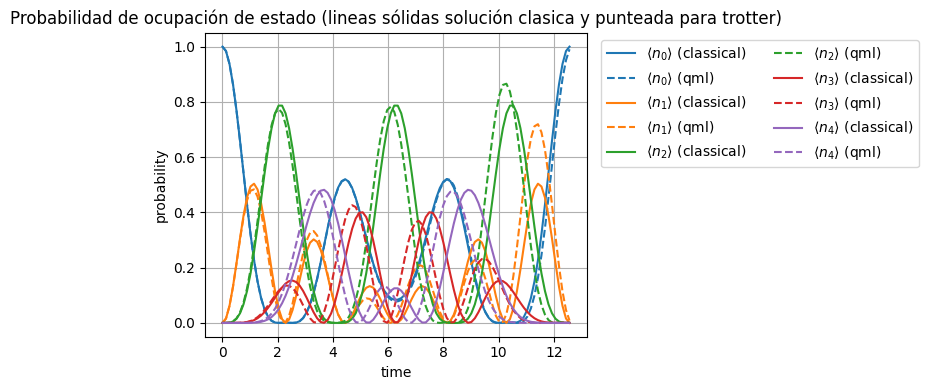

In [ ]:
import matplotlib.pyplot as plt

labels_classical = [r"$\langle n_{" + str(i) + r"}\rangle$ (classical)" for i in range(num_sites)]
labels_qml = [r"$\langle n_{" + str(i) + r"}\rangle$ (qml)" for i in range(num_sites)]

plt.figure(figsize=(8, 4))

lines = []
labels = []

colors = plt.cm.tab10.colors

for j in range(num_sites):
    color = colors[j % len(colors)]
    line_classical, = plt.plot(times, evo_matrix_classical[:, j], linestyle="-", color=color)
    lines.append(line_classical)
    labels.append(labels_classical[j])

    line_qml, = plt.plot(times, evo_matrix_qml[:, j], linestyle="--", color=color)
    lines.append(line_qml)
    labels.append(labels_qml[j])

plt.xlabel("time")
plt.ylabel("probability")
plt.title("Probabilidad de ocupación de estado (lineas sólidas solución clasica y punteada para trotter)")
plt.grid()

plt.legend(lines, labels, ncol=2, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


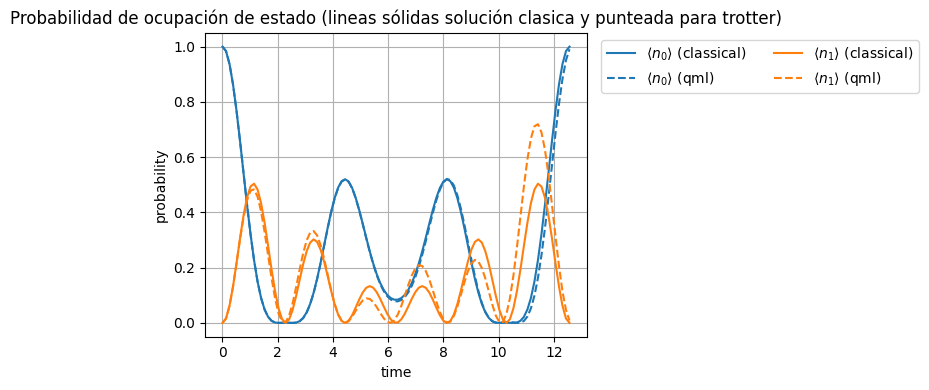

In [ ]:
import matplotlib.pyplot as plt

labels_classical = [r"$\langle n_{" + str(i) + r"}\rangle$ (classical)" for i in range(num_sites)]
labels_qml = [r"$\langle n_{" + str(i) + r"}\rangle$ (qml)" for i in range(num_sites)]

plt.figure(figsize=(8, 4))

lines = []
labels = []

colors = plt.cm.tab10.colors

for j in range(2):
    color = colors[j % len(colors)]
    line_classical, = plt.plot(times, evo_matrix_classical[:, j], linestyle="-", color=color)
    lines.append(line_classical)
    labels.append(labels_classical[j])

    line_qml, = plt.plot(times, evo_matrix_qml[:, j], linestyle="--", color=color)
    lines.append(line_qml)
    labels.append(labels_qml[j])

plt.xlabel("time")
plt.ylabel("probability")
plt.title("Probabilidad de ocupación de estado (lineas sólidas solución clasica y punteada para trotter)")
plt.grid()

plt.legend(lines, labels, ncol=2, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


Podemos ver la manera en la que el error se acumula con el paso del tiempo. Es importante mencionar que para 5 partículas el método clásico computó casi que instantaneamente y trotter se demoró 4 segundos. Esto nos muestra que para pocas partículas el método clásico es el más eficiente. Por otro lado, si se intenta correr para 10 partículas, el clásico demora aproximadamente 6 minutos y trotter toma 6 segundos, lo que muestra la manera en la que la complejidad del Hamiltoniano aumenta.

/tmp/ipython-input-1956650270.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


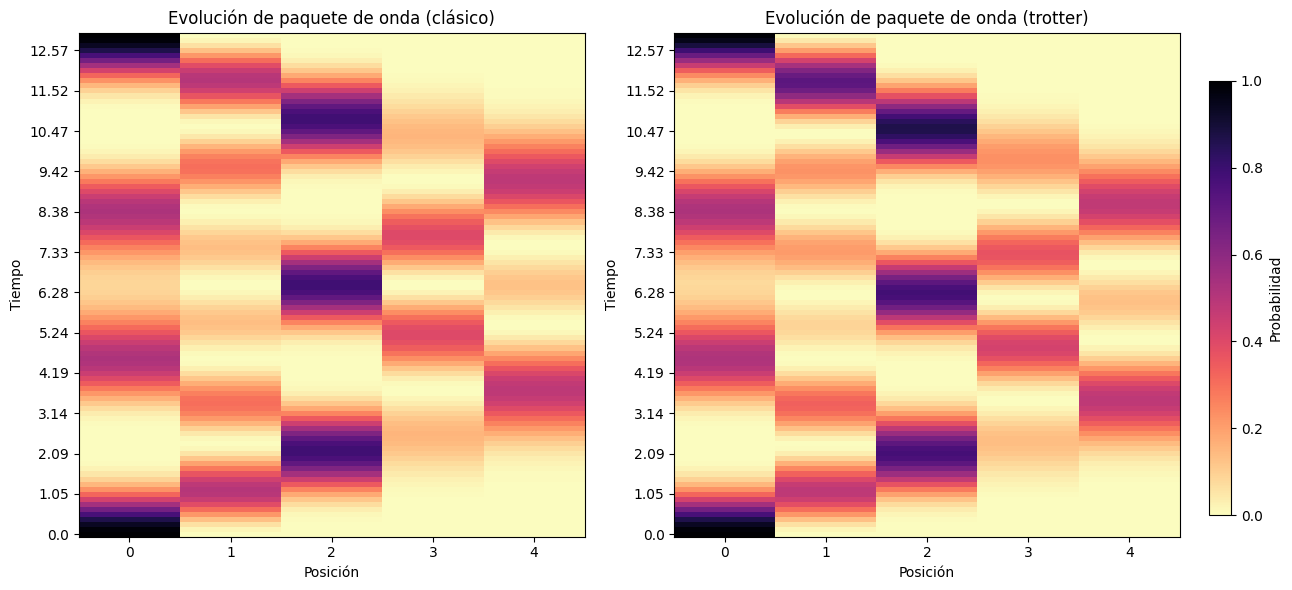

In [ ]:
import math

fig, axs = plt.subplots(1, 2, figsize=(12, 6))  # 1 fila, 2 columnas

# Gráfico evolución clásica
im0 = axs[0].imshow(evo_matrix_classical, origin="lower", aspect="auto", vmin=0, vmax=1, cmap="magma_r")
axs[0].set_xticks(np.arange(num_sites))
axs[0].set_xticklabels(np.arange(num_sites))
axs[0].set_yticks(np.arange(0, evo_matrix_classical.shape[0], 8))
axs[0].set_yticklabels(np.round(np.linspace(0, 4 * np.pi, num=math.ceil(evo_matrix_classical.shape[0]/8)), 2)[:len(np.arange(0, evo_matrix_classical.shape[0], 8))])
axs[0].set_ylabel("Tiempo")
axs[0].set_xlabel("Posición")
axs[0].set_title("Evolución de paquete de onda (clásico)")

# Gráfico evolución trotterizada
im1 = axs[1].imshow(evo_matrix_qml, origin="lower", aspect="auto", vmin=0, vmax=1, cmap="magma_r")
axs[1].set_xticks(np.arange(num_sites))
axs[1].set_xticklabels(np.arange(num_sites))
axs[1].set_yticks(np.arange(0, evo_matrix_qml.shape[0], 8))
axs[1].set_yticklabels(np.round(np.linspace(0, 4 * np.pi, num=math.ceil(evo_matrix_qml.shape[0]/8)), 2)[:len(np.arange(0, evo_matrix_qml.shape[0], 8))])
axs[1].set_ylabel("Tiempo")
axs[1].set_xlabel("Posición")
axs[1].set_title("Evolución de paquete de onda (trotter)")

# Colorbar común a ambos
fig.subplots_adjust(right=1.03)
cbar = fig.colorbar(im1, ax=axs, orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_label("Probabilidad")

plt.tight_layout()
plt.show()

Y por último, para confirmar la coherencia de los resultados, se verifica el número de electrones en todas las ubicaciones. De esta manera podemos ver que en todos los pasos se haya conservado el número de electrones.

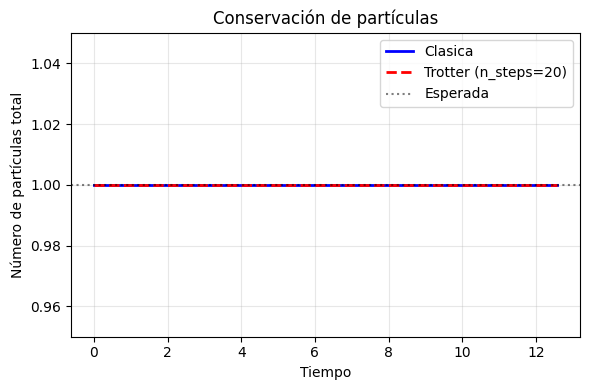

In [ ]:
# Chequeo de conservación de partículas

plt.figure(figsize=(6, 4))

# Clásico
classical_sum = np.sum(evo_matrix_classical, axis=1)
plt.plot(times, classical_sum, 'b-', linewidth=2, label="Clasica")

# Trotter
trotter_sum = np.sum(evo_matrix_qml, axis=1)
plt.plot(times, trotter_sum, 'r--', linewidth=2, label=f"Trotter (n_steps={n_steps_trotter})")

# Línea de referencia (1 electrón)
plt.axhline(1.0, color='k', linestyle=':', alpha=0.5, label="Esperada")

plt.ylim(0.95, 1.05)
plt.xlabel("Tiempo")
plt.ylabel("Número de partículas total")
plt.title("Conservación de partículas")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

## Conclusiones


1. Se logró reproducir la dinámica del modelo de Ising con campo magnético transversal y del modelo tight-binding, ambos fundamentales en la descripción de sistemas de espines y electrones en redes cristalinas.

2. La implementación en PennyLane demostró que la descomposición de Trotter permite aproximar de manera eficiente la evolución temporal de sistemas cuánticos descritos por Hamiltonianos no triviales.


## Referencias


[1] Michael A Nielsen and Isaac L Chuang. Quantum computation and quantum infor-
mation. Cambridge Cambridge University Press, 2010.

[2] Dojo nativo cuántico. https://dojo.qulacs.org/en/latest/notebooks/4.2_trotter_decomposition.html

[3] Roy, Mervyn. "The tight binding method." Rutgers University 5 (2015): 57.

[4] Ferris, Kaelyn J, et al. “Quantum Simulation on Noisy Superconducting Quantum Computers.” ArXiv (Cornell University), 1 Jan. 2022, https://doi.org/10.48550/arxiv.2209.02795.

[5] qiskit-community. “Tutorial-Quantum-Sim/Docs/Qsim-Tight-Binding-Model.ipynb at Main · Qiskit-Community/Tutorial-Quantum-Sim.” GitHub, 2025, github.com/qiskit-community/tutorial-quantum-sim/blob/main/docs/qsim-tight-binding-model.ipynb.